In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Load data with features already extracted
df = pd.read_pickle('features_extracted.pkl')
df.head()

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,...,word_count,lyrics_preproc_v2,tokens,ttr,avg_word_length,repetition_ratio,max_word_freq,bigram_repetition_ratio,sentiment_polarity,sentiment_intensity
19,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.155,77.639,-7.746,...,172,rotgut whiskey gon ease mind beach towel rest ...,"[rotgut, whiskey, gon, ease, mind, beach, towe...",0.467456,5.011834,0.041420,7,0.017857,0.8750,0.8750
43,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.620,78.558,-9.222,...,268,okay okay okay okay okay okay live dream state...,"[okay, okay, okay, okay, okay, okay, live, dre...",0.394495,4.527523,0.160550,35,0.147465,0.9865,0.9865
195,17phhZDn6oGtzMe56NuWvj,Lose Control,Teddy Swims,I've Tried Everything But Therapy (Part 1),2023-09-15,0.561,0.604,0.242,159.920,-4.409,...,123,something got hold lately know anymore feel li...,"[something, got, hold, lately, know, anymore, ...",0.587719,4.798246,0.052632,6,0.053097,-0.9568,0.9568
11,4iZ4pt7kvcaH6Yo8UoZ4s2,Snooze,SZA,SOS,2022-12-09,0.559,0.551,0.392,143.008,-7.231,...,177,think know touch fire three four time testify ...,"[think, know, touch, fire, three, four, time, ...",0.461988,4.807018,0.076023,13,0.058824,-0.9755,0.9755
24,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,SZA,SOS,2022-12-08,0.644,0.735,0.418,88.980,-5.747,...,150,still fan even though salty hate see broad kno...,"[still, fan, even, though, salty, hate, see, b...",0.459459,4.594595,0.054054,8,0.027211,-0.9740,0.9740


## Topic Modeling with Latent Dirichlet Allocation (LDA)

We use LDA to identify common lyrical themes in the dataset. We'll build a count matrix from our clean text and experiment with different numbers of topics.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Step 1 — Build the Corpus (Bag-of-Words)
# We use the clean text string (lyrics_preproc_v2)
cv = CountVectorizer(
    min_df=5,       # word must appear in at least 5 documents
    max_df=0.85,    # ignore words appearing in >85% of docs
    max_features=3000,
    ngram_range=(1, 2)
)
count_matrix = cv.fit_transform(df["lyrics_preproc_v2"])
count_matrix.shape

(684, 3000)

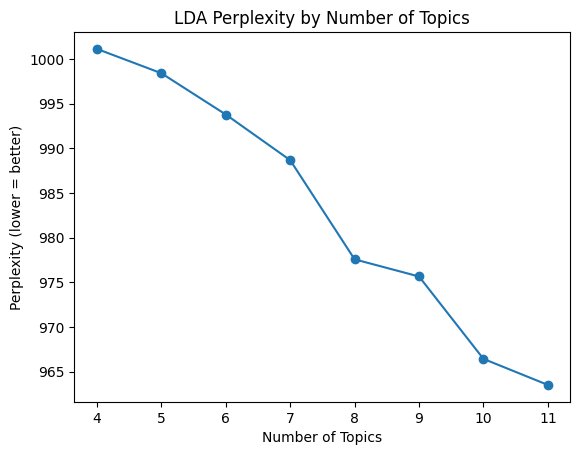

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# Step 2 — Choose Number of Topics (k) - Perplexity check
# Note: running this may take a few seconds
perplexities = []
ks = range(4, 12)
for k in ks:
    lda = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=20)
    lda.fit(count_matrix)
    perplexities.append(lda.perplexity(count_matrix))

plt.plot(list(ks), perplexities, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity (lower = better)")
plt.title("LDA Perplexity by Number of Topics")
plt.show()

Based on expected themes (e.g., love, street, party, sadness, etc.) and evaluating the perplexity, we fit the LDA model with $K=7$ topics.

In [18]:
# Step 3 — Fit the LDA model
K = 9

lda_final = LatentDirichletAllocation(
    n_components=K,
    random_state=42,
    max_iter=50,
    learning_method="batch"
)
lda_final.fit(count_matrix)

# Step 4 — Inspect Topics (Print Top Words per Topic)
feature_names = cv.get_feature_names_out()

for i, topic in enumerate(lda_final.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:]][::-1]
    print(f"Topic {i}: ", ", ".join(top_words))

Topic 0:  got, like, let, hold, go, okay, get, got ta, ta, baby, love, know, fuck, make, club
Topic 1:  one, baby, dance, know, like, got, come, face, mine, way, said, cause, girl, shit, never
Topic 2:  know, like, get, night, baby, time, right, life, love, want, cause, never, let, could, girl
Topic 3:  nigga, bitch, got, like, shit, fuck, get, one, em, know, lil, gettin, ho, as, tell
Topic 4:  christmas, wish, home, talk, say, way, take, time, go, night, back, make, year, come, merry
Topic 5:  ha, keep, ha ha, like, bum, falling, baby, give, gon, star, fast, come, better, wait, say
Topic 6:  like, got, know, get, shit, bout, back, go, one, man, cause, nigga, fuck, talkin, gon
Topic 7:  love, love love, stop, shake, yet, good, girl, trust, ex, gon, round, beat, say, stop stop, hand
Topic 8:  santa, need, like, wock, tell, real, cause, baby, make, want, town, love, let, day, somethin


Now we extract the topic distributions as features for each song, finding the dominant topic and topic confidence.

In [19]:
# Step 5 — Extract Per-Song Topic Distributions
topic_dist = lda_final.transform(count_matrix)  # shape: (790, K)

topic_cols = [f"topic_{i}" for i in range(K)]
topic_df = pd.DataFrame(topic_dist, columns=topic_cols, index=df.index)

# Drop existing topic columns if we are re-running
cols_to_drop = [c for c in df.columns if c in topic_cols or c in ["dominant_topic", "topic_confidence"]]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Add topic distributions to main dataframe
df = pd.concat([df, topic_df], axis=1)

# Step 6 — Derive a Summary Feature: Dominant Topic
df["dominant_topic"] = topic_dist.argmax(axis=1)
df["topic_confidence"] = topic_dist.max(axis=1)  # how "pure" the assignment is

df[["lyrics_preproc_v2", "dominant_topic", "topic_confidence"]].head()

,lyrics_preproc_v2,dominant_topic,topic_confidence
19,rotgut whiskey gon ease mind beach towel rest ...,2,0.500833
43,okay okay okay okay okay okay live dream state...,0,0.996457
195,something got hold lately know anymore feel li...,2,0.608854
11,think know touch fire three four time testify ...,6,0.775793
24,still fan even though salty hate see broad kno...,1,0.564692


### Visualizing Dominant Topics and Chart Persistence

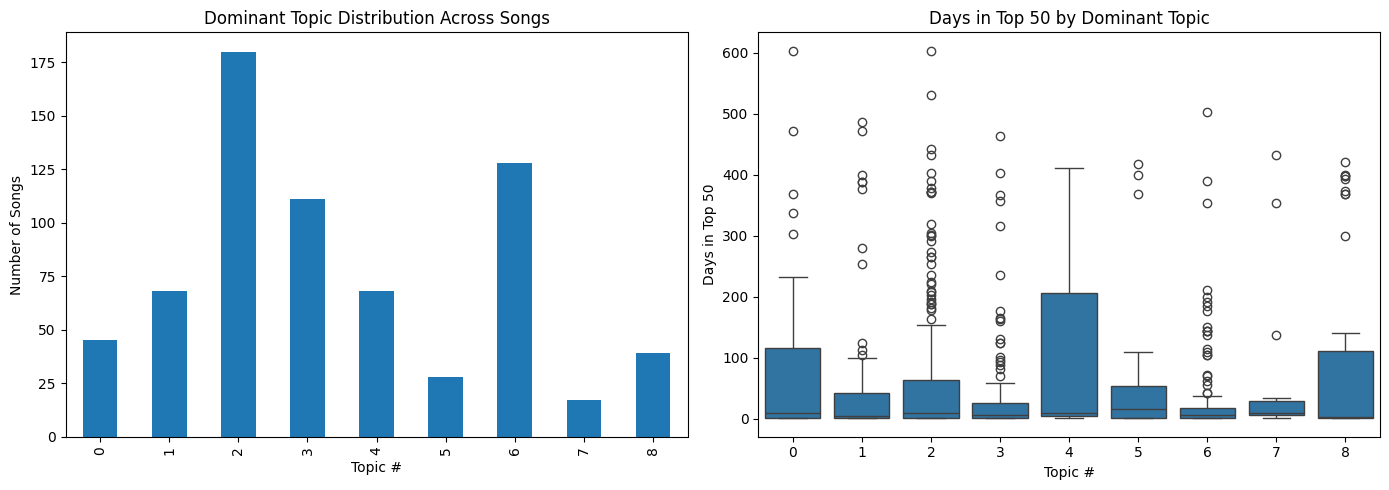

In [20]:
# Step 7 — Visualize
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Topic distribution across the corpus
df["dominant_topic"].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title("Dominant Topic Distribution Across Songs")
axes[0].set_xlabel("Topic #")
axes[0].set_ylabel("Number of Songs")

# b) Topic vs. days_in_top50 (boxplot)
sns.boxplot(x="dominant_topic", y="days_in_top50", data=df, ax=axes[1])
axes[1].set_title("Days in Top 50 by Dominant Topic")
axes[1].set_xlabel("Topic #")
axes[1].set_ylabel("Days in Top 50")

plt.tight_layout()
plt.show()

### Top 5 Songs per Topic

Here we find the 5 songs most strongly associated with each topic (highest topic probability) and visualize them.

/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_9762/114097973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[f"topic_{i}"], y=labels, ax=ax, palette="viridis")
/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_9762/114097973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[f"topic_{i}"], y=labels, ax=ax, palette="viridis")
/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_9762/114097973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[f"topic_{i}"], y=labels, ax=

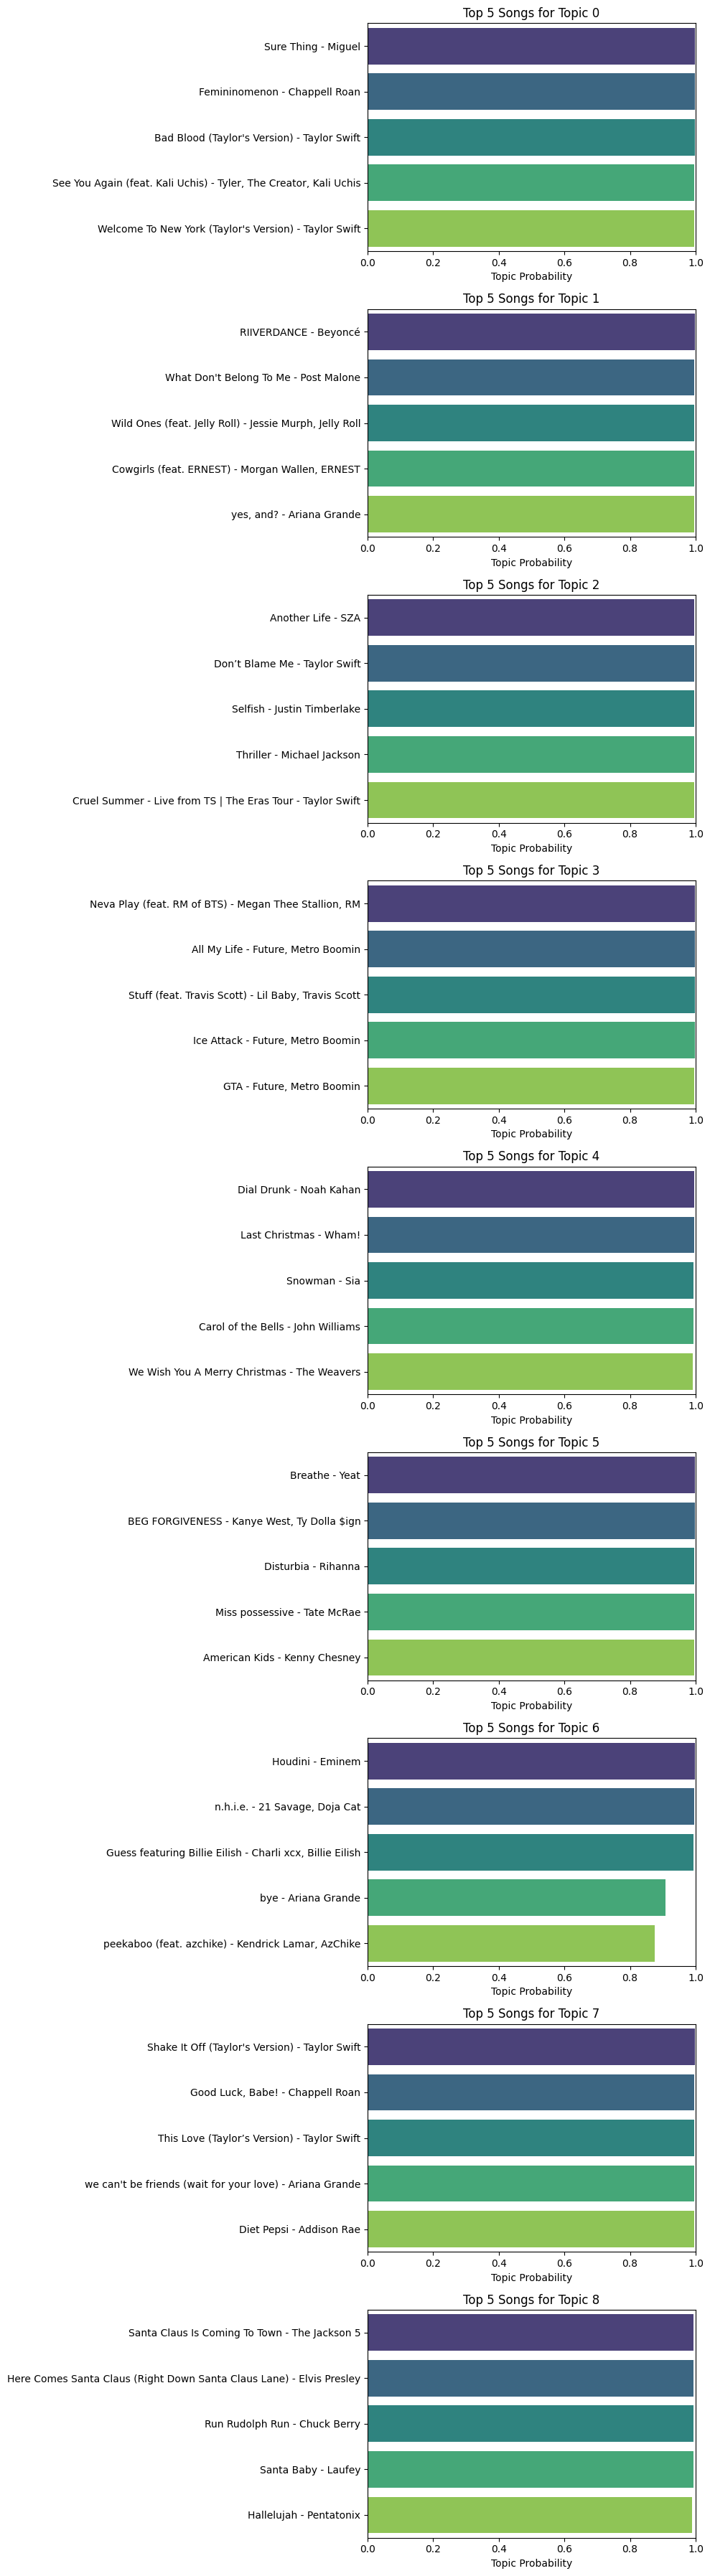

In [23]:
fig, axes = plt.subplots(K, 1, figsize=(10, 4 * K), sharex=False)
plt.subplots_adjust(hspace=0.5)

for i in range(K):
    # Get top 5 songs for topic i with highest probability
    top_songs = df.sort_values(by=f"topic_{i}", ascending=False).head(5)
    
    # Combine song name and artist for better context in plots
    labels = top_songs["name"] + " - " + top_songs["artists"]
    
    ax = axes[i]
    sns.barplot(x=top_songs[f"topic_{i}"], y=labels, ax=ax, palette="viridis")
    
    ax.set_title(f"Top 5 Songs for Topic {i}")
    ax.set_xlabel("Topic Probability")
    ax.set_ylabel("")
    ax.set_xlim(0, 1) # Probability is between 0 and 1

plt.tight_layout()
plt.show()

Finally, we save the resulting dataset enriched with text features and topic distributions.

In [22]:
# Step 8 — Save the enriched DataFrame
df.to_pickle("lyrics_with_topics.pkl")
df.to_csv("lyrics_with_topics.csv", index=False)